# <center>Linear Regression From Scratch<center>

## Table of Contents
1. Closed form
2. Gradient descent
3. Stochastic gradient descent
4. Mini batch gradient descent
5. Singular Value Decomposition (SVD)
6. Ridge
7. ~~Lasso~~
8. Polynomial regression
9. Time comparison

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from linear_regression import Linear_Regression
from metrics import MSE, RMSE

# importing dataset
path = '../data/happiness2016.csv'

df = pd.read_csv(path)

#### Checking data

In [2]:
df.head()

,Country,Region,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Denmark,Western Europe,1,7.526,7.460,7.592,1.44178,1.16374,0.79504,0.57941,0.44453,0.36171,2.73939
1,Switzerland,Western Europe,2,7.509,7.428,7.590,1.52733,1.14524,0.86303,0.58557,0.41203,0.28083,2.69463
2,Iceland,Western Europe,3,7.501,7.333,7.669,1.42666,1.18326,0.86733,0.56624,0.14975,0.47678,2.83137
3,Norway,Western Europe,4,7.498,7.421,7.575,1.57744,1.12690,0.79579,0.59609,0.35776,0.37895,2.66465
4,Finland,Western Europe,5,7.413,7.351,7.475,1.40598,1.13464,0.81091,0.57104,0.41004,0.25492,2.82596


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        157 non-null    str    
 1   Region                         157 non-null    str    
 2   Happiness Rank                 157 non-null    int64  
 3   Happiness Score                157 non-null    float64
 4   Lower Confidence Interval      157 non-null    float64
 5   Upper Confidence Interval      157 non-null    float64
 6   Economy (GDP per Capita)       157 non-null    float64
 7   Family                         157 non-null    float64
 8   Health (Life Expectancy)       157 non-null    float64
 9   Freedom                        157 non-null    float64
 10  Trust (Government Corruption)  157 non-null    float64
 11  Generosity                     157 non-null    float64
 12  Dystopia Residual              157 non-null    float64
dtypes

### Dataset Description

Dataset represents factors that have more or less influence on people's happiness in 157 countries in 2015. Each row corresponds to one country.

* **Country** – country name
* **Region** – region of the country
* **Happiness Rank** – country's rank according to the happiness score
* **Happiness Score** – average happiness score (0–10)
* **Lower Confidence Interval** – lower bound of the confidence interval for the happiness score
* **Upper Confidence Interval** – upper bound of the confidence interval for the happiness score
* **Economy (GDP per Capita)** – GDP contribution to the happiness score
* **Family** – family support contribution to the score
* **Health (Life Expectancy)** – life expectancy contribution to the score
* **Freedom** – feeling of freedom contribution to the score
* **Trust (Government Corruption)** – perception of corruption contribution to the score
* **Generosity** – generosity contribution to the score
* **Dystopia Residual** – difference between predicted and observed happiness not explained by other factors

#### Visualizing data

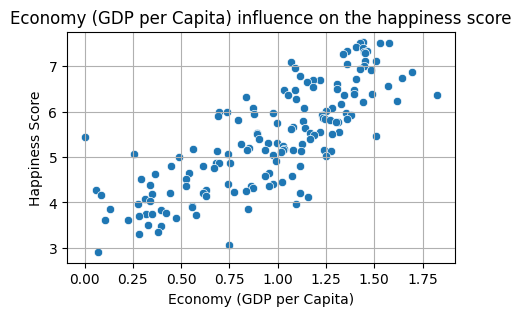

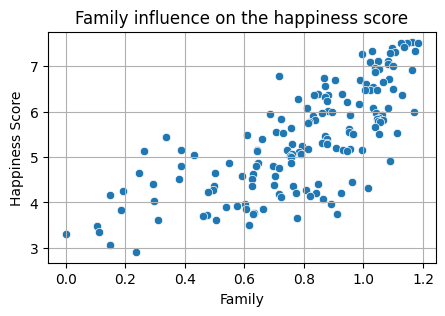

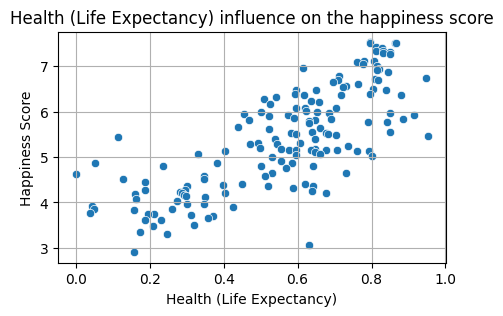

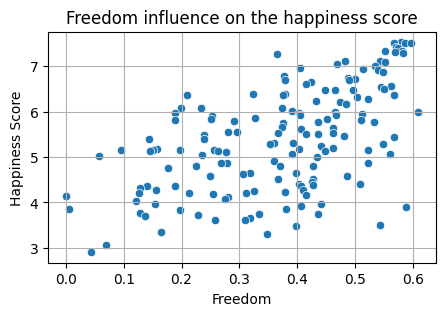

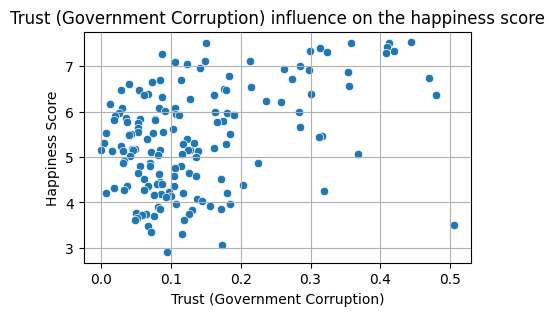

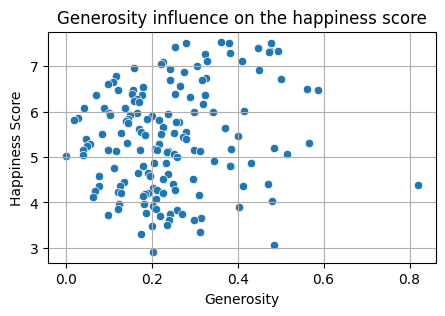

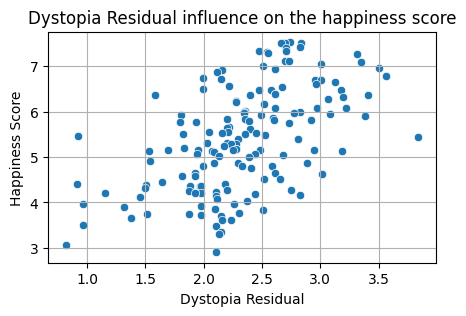

In [4]:
features = [
    'Economy (GDP per Capita)',
    'Family', 
    'Health (Life Expectancy)', 
    'Freedom',
    'Trust (Government Corruption)', 
    'Generosity',
    'Dystopia Residual'
]

for feature in features:
    plt.figure(figsize=(5, 3))
    sns.scatterplot(data=df, x=feature, y='Happiness Score')
    plt.grid(True)
    plt.title(f'{feature} influence on the happiness score')
    plt.show()

---

### **Closed form**

Error:
0.6972626334828966
Final function:
y = [2.18686322]X + 3.296180041308007
Error:
0.00029323944326990363
Final function:
y = [0.99999088 1.00002422 0.99985263 1.00016829 0.99970066 1.00017439
 0.99994759]X + 0.0001357357434505694


Text(0, 0.5, 'Happiness Score')

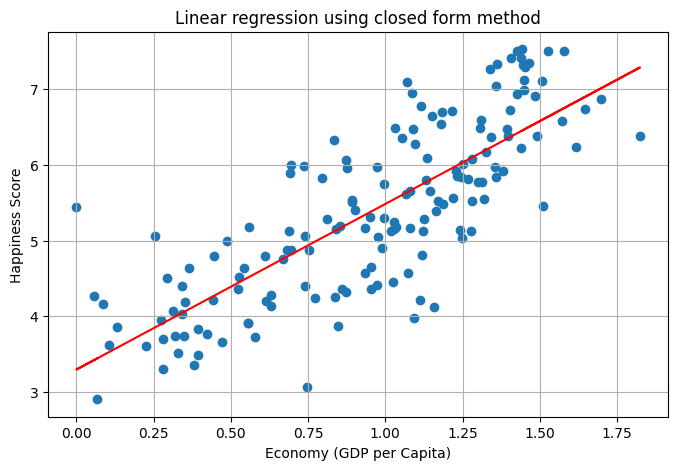

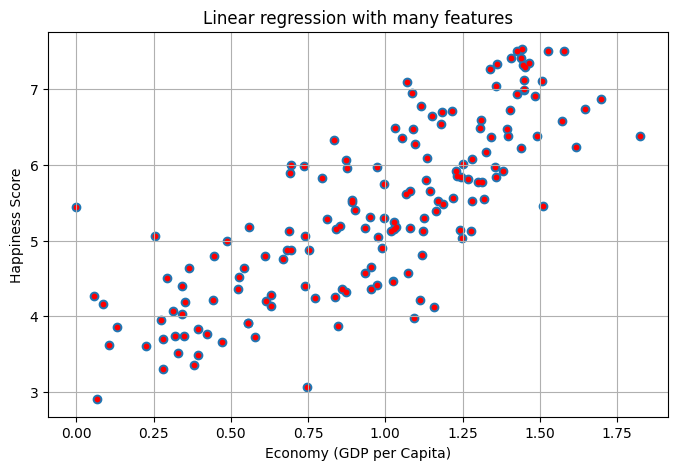

In [5]:
from closed_form import Linear_Regression_Closed_Form

X = df['Economy (GDP per Capita)'].to_numpy()
y = df['Happiness Score'].to_numpy()

closed_form = Linear_Regression_Closed_Form()
closed_form.fit(X, y)

y_pred = closed_form.predict(X)

print(f'Error:\n{RMSE(y, y_pred)}')
print(f'Final function:\ny = {closed_form.weights}X + {closed_form.bias}')

plt.figure(figsize=(8, 5))
plt.scatter(X, y, label='Data')
plt.plot(X, y_pred, color='red', label='Closed form')
plt.grid(True)
plt.title('Linear regression using closed form method')
plt.xlabel('Economy (GDP per Capita)')
plt.ylabel('Happiness Score')

X = df[features].to_numpy()
y = df['Happiness Score'].to_numpy()

closed_form = Linear_Regression_Closed_Form()
closed_form.fit(X, y)

y_pred = closed_form.predict(X)

print(f'Error:\n{RMSE(y, y_pred)}')
print(f'Final function:\ny = {closed_form.weights}X + {closed_form.bias}')

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], y, label='Data')
plt.scatter(X[:, 0], y_pred, color='red', s=10, label='Prediction')
plt.grid(True)
plt.title('Linear regression with many features')
plt.xlabel('Economy (GDP per Capita)')
plt.ylabel('Happiness Score')

---

### **Gradient descent**

RMSE: [4.8300366]
RMSE: [1.77983666]
RMSE: [0.93817651]
RMSE: [0.78778407]
RMSE: [0.76886282]
RMSE: [0.7666857]
RMSE: [0.7664376]
RMSE: [0.76640879]
RMSE: [0.76640489]
RMSE: [0.76640384]
RMSE: [0.76640313]
RMSE: [0.76640248]
RMSE: [0.76640185]
RMSE: [0.76640125]
RMSE: [0.76640067]
RMSE: [0.76640011]
RMSE: [0.76639956]
RMSE: [0.76639904]
RMSE: [0.76639853]
RMSE: [0.76639804]
RMSE: [0.76639757]
RMSE: [0.76639711]
RMSE: [0.76639667]
RMSE: [0.76639624]
RMSE: [0.76639583]
RMSE: [0.76639543]
RMSE: [0.76639504]
RMSE: [0.76639467]
RMSE: [0.76639431]
RMSE: [0.76639396]
RMSE: [0.76639363]
RMSE: [0.7663933]
RMSE: [0.76639299]
RMSE: [0.76639269]
RMSE: [0.76639239]
RMSE: [0.76639211]
RMSE: [0.76639184]
RMSE: [0.76639157]
RMSE: [0.76639132]
RMSE: [0.76639107]
RMSE: [0.76639083]
RMSE: [0.7663906]
RMSE: [0.76639038]
RMSE: [0.76639017]
RMSE: [0.76638996]
RMSE: [0.76638976]
RMSE: [0.76638957]
RMSE: [0.76638938]
RMSE: [0.7663892]
RMSE: [0.76638902]
RMSE: [0.76638885]
RMSE: [0.76638869]
RMSE: [0.76638853]

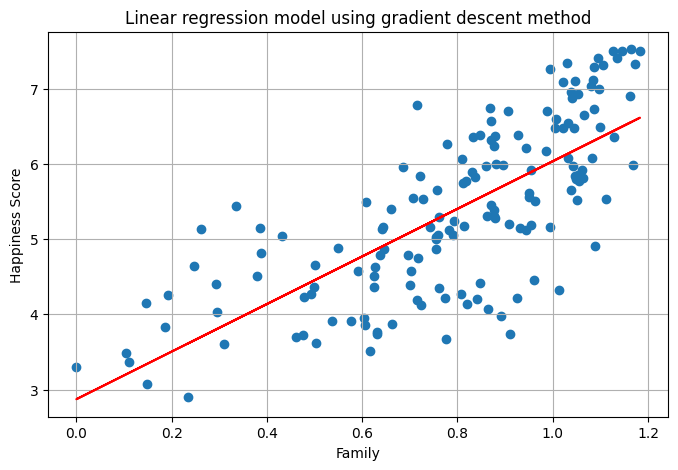

In [6]:
from gradient_descent import Linear_Regression_Gradient

X = df['Family'].to_numpy()
y = df['Happiness Score'].to_numpy()

gradient_descent = Linear_Regression_Gradient()

gradient_descent.fit(X, y, max_iters=1000, lr=0.2, stats=True)
y_pred = gradient_descent.predict(X)

print(f'Final function:\ny = {gradient_descent.weights}x + {gradient_descent.bias}')

plt.figure(figsize=(8, 5))
plt.scatter(X, y, label='Data')
plt.plot(X, y_pred, color='red', label='Gradient descent')
plt.xlabel('Family')
plt.ylabel('Happiness Score')
plt.title('Linear regression model using gradient descent method')
plt.grid()

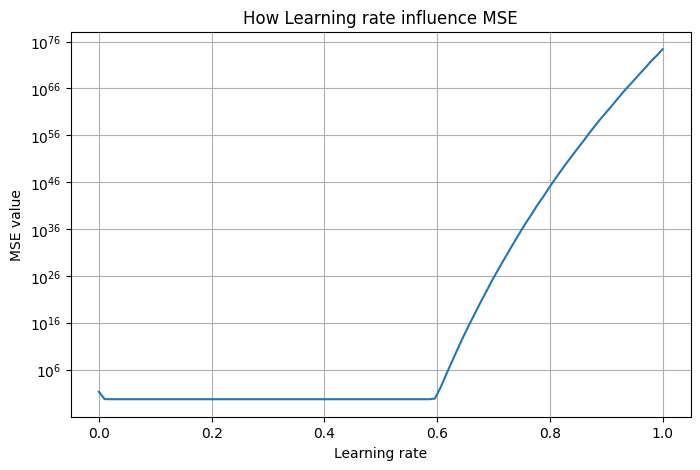

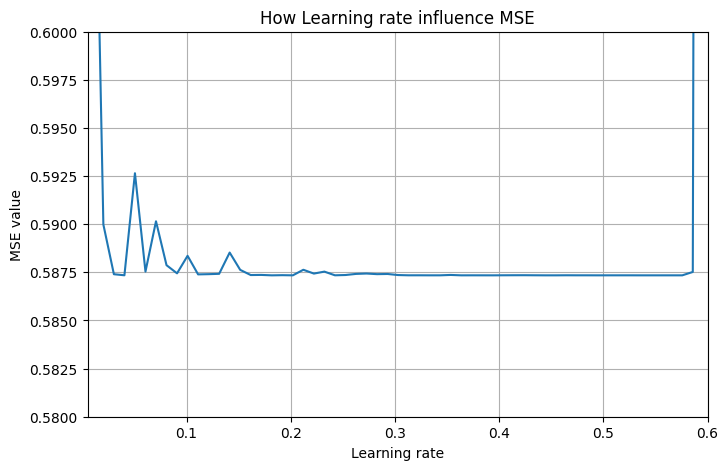

In [7]:
# === Learning rate test ===
learning_rate = np.linspace(0, 1, 100)
errors = []

for alpha in learning_rate:
    lr_test = Linear_Regression_Gradient()
    gradient_descent.fit(X, y, max_iters=100, lr=alpha, stats=False)
    y_pred = gradient_descent.predict(X)

    errors.append(MSE(y, y_pred))

plt.figure(figsize=(8, 5))
plt.plot(learning_rate, errors)
plt.yscale('log')
plt.xlabel('Learning rate')
plt.ylabel('MSE value')
plt.title('How Learning rate influence MSE')
plt.grid()

plt.figure(figsize=(8, 5))
plt.plot(learning_rate, errors)
plt.xlim(0.005, 0.6)
plt.ylim(0.58, 0.6)
plt.xlabel('Learning rate')
plt.ylabel('MSE value')
plt.title('How Learning rate influence MSE')
plt.grid()


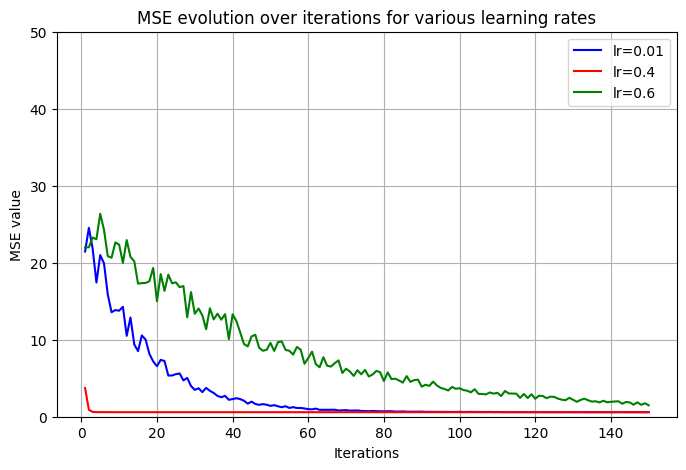

In [8]:
# === Iteration test ===
iterations = np.linspace(1, 150, 150, dtype=int)
learning_rate = [0.01, 0.4, 0.6]

errors = []
for alpha in learning_rate:
    error = []
    for iter in iterations:
        iter_test = Linear_Regression_Gradient()
        gradient_descent.fit(X, y, max_iters=iter, lr=alpha, stats=False)
        y_pred = gradient_descent.predict(X)

        error.append(MSE(y, y_pred))
    errors.append(error)


plt.figure(figsize=(8, 5))
plt.plot(iterations, errors[0], color='blue', label='lr=0.01')
plt.plot(iterations, errors[1], color='red', label='lr=0.4')
plt.plot(iterations, errors[2], color ='green', label='lr=0.6')
plt.ylim(0, 50)
plt.xlabel('Iterations')
plt.ylabel('MSE value')
plt.title('MSE evolution over iterations for various learning rates')
plt.legend()
plt.grid()


---

### **Stochastic gradient descent**

RMSE: [1.13028034]
RMSE: [0.00917791]
RMSE: [1.38417046]
RMSE: [0.04995616]
RMSE: [0.00836074]
RMSE: [0.66609879]
RMSE: [0.05763645]
RMSE: [0.48377747]
RMSE: [0.11674293]
RMSE: [0.80532872]
RMSE: [0.56527829]
RMSE: [0.11122085]
RMSE: [0.15740042]
RMSE: [0.19412282]
RMSE: [0.69048473]
RMSE: [0.47700044]
RMSE: [0.94989269]
RMSE: [0.10308705]
RMSE: [0.37119706]
RMSE: [0.56080427]
RMSE: [0.5364598]
RMSE: [1.329024]
RMSE: [1.12903816]
RMSE: [0.86856169]
RMSE: [0.45011984]
RMSE: [1.01009906]
RMSE: [1.0312379]
RMSE: [0.00349168]
RMSE: [0.0212595]
RMSE: [0.68678491]
RMSE: [0.01236546]
RMSE: [0.63310148]
RMSE: [0.71300627]
RMSE: [0.15083932]
RMSE: [0.33081824]
RMSE: [0.30852804]
RMSE: [1.03268059]
RMSE: [0.47136191]
RMSE: [0.14540091]
RMSE: [0.54466862]
RMSE: [1.23149372]
RMSE: [0.13421528]
RMSE: [0.25160467]
RMSE: [0.2826399]
RMSE: [0.63944702]
RMSE: [0.54310515]
RMSE: [0.8017304]
RMSE: [0.48482813]
RMSE: [0.73801356]
RMSE: [1.12268311]
RMSE: [0.17960398]
RMSE: [0.57397843]
RMSE: [0.56297462]


Text(0.5, 1.0, 'Linear regression model using stochastic gradient descent method')

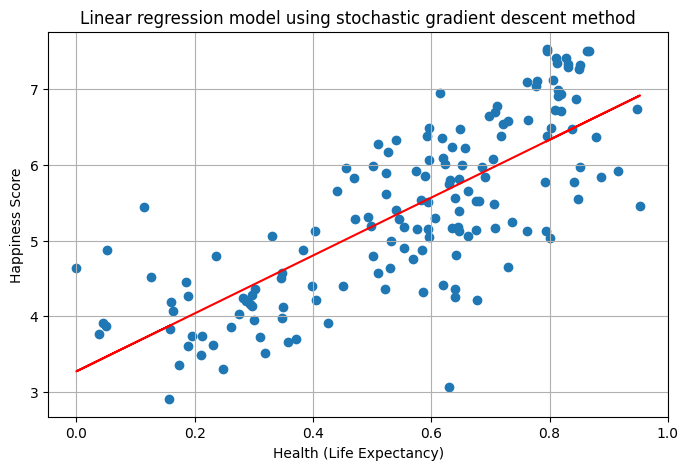

In [9]:
from stochastic_gd import Linear_Regression_Stochastic_GD

X = df['Health (Life Expectancy)'].to_numpy()
y = df['Happiness Score'].to_numpy()

stochastic = Linear_Regression_Stochastic_GD()
stochastic.fit(X, y, max_iters=100, lr=0.02, stats=True)

y_pred = stochastic.predict(X)

print(f'Final function\ny = {stochastic.weights}x + {stochastic.bias}')

plt.figure(figsize=(8, 5))
plt.scatter(X, y, label='Data')
plt.plot(X, y_pred, color='red', label='Stochastic gradient descent')
plt.grid()
plt.xlabel('Health (Life Expectancy)')
plt.ylabel('Happiness Score')
plt.title('Linear regression model using stochastic gradient descent method')

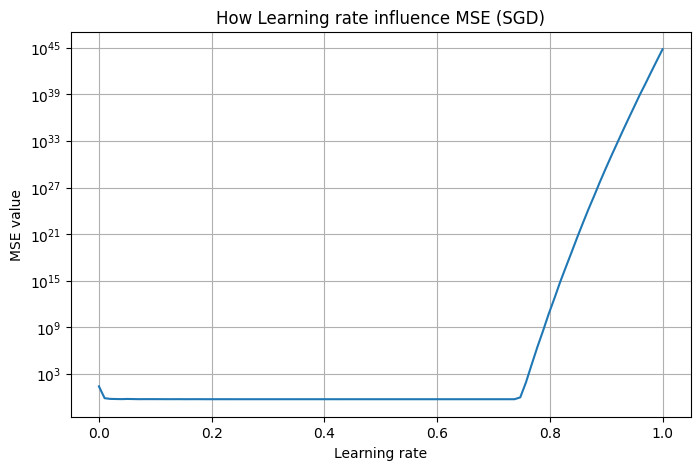

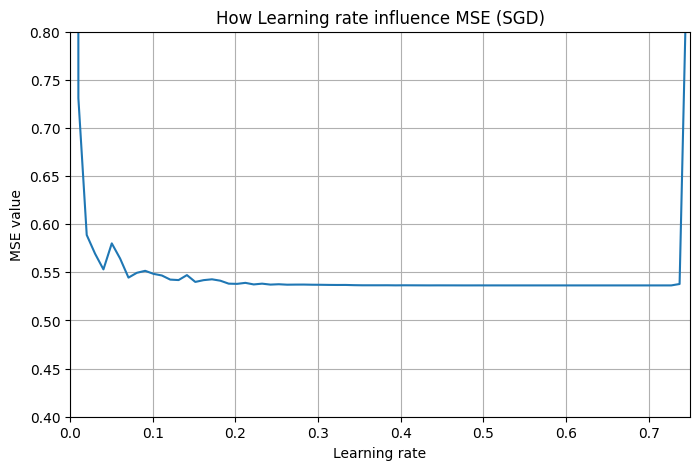

In [10]:
# === Learning rate test ===
learning_rate = np.linspace(0, 1, 100)
errors = []

for alpha in learning_rate:
    lr_test = Linear_Regression_Stochastic_GD()
    gradient_descent.fit(X, y, max_iters=100, lr=alpha, stats=False)
    y_pred = gradient_descent.predict(X)

    errors.append(MSE(y, y_pred))

plt.figure(figsize=(8, 5))
plt.plot(learning_rate, errors)
plt.yscale('log')
plt.xlabel('Learning rate')
plt.ylabel('MSE value')
plt.title('How Learning rate influence MSE (SGD)')
plt.grid()

plt.figure(figsize=(8, 5))
plt.plot(learning_rate, errors)
plt.xlim(0, 0.75)
plt.ylim(0.4, 0.8)
plt.xlabel('Learning rate')
plt.ylabel('MSE value')
plt.title('How Learning rate influence MSE (SGD)')
plt.grid()

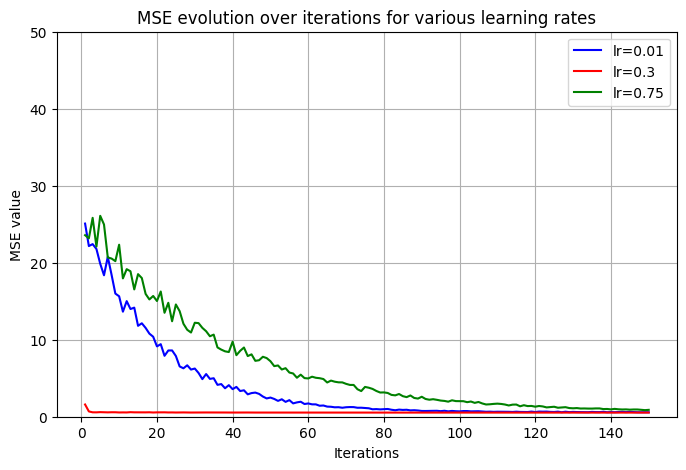

In [11]:
# === Iteration test ===
iterations = np.linspace(1, 150, 150, dtype=int)
learning_rate = [0.01, 0.3, 0.75]

errors = []
for alpha in learning_rate:
    error = []
    for iter in iterations:
        iter_test = Linear_Regression_Stochastic_GD()
        gradient_descent.fit(X, y, max_iters=iter, lr=alpha, stats=False)
        y_pred = gradient_descent.predict(X)

        error.append(MSE(y, y_pred))
    errors.append(error)


plt.figure(figsize=(8, 5))
plt.plot(iterations, errors[0], color='blue', label=f'lr={learning_rate[0]}')
plt.plot(iterations, errors[1], color='red', label=f'lr={learning_rate[1]}')
plt.plot(iterations, errors[2], color ='green', label=f'lr={learning_rate[2]}')
plt.ylim(0, 50)
plt.xlabel('Iterations')
plt.ylabel('MSE value')
plt.title('MSE evolution over iterations for various learning rates')
plt.legend()
plt.grid()


---

### **Mini batch**

RMSE: [1.14424425]
RMSE: [1.05450134]
RMSE: [0.99174075]
RMSE: [1.10084649]
RMSE: [0.9151234]
RMSE: [0.90944501]
RMSE: [0.95525508]
RMSE: [1.02775745]
RMSE: [1.02444455]
RMSE: [0.84619038]
RMSE: [0.87791364]
RMSE: [0.89650131]
RMSE: [0.97109175]
RMSE: [1.00495971]
RMSE: [0.87409421]
RMSE: [0.86401484]
RMSE: [0.96346324]
RMSE: [1.03333225]
RMSE: [0.98670394]
RMSE: [0.85677165]
RMSE: [0.7639444]
RMSE: [1.05136125]
RMSE: [1.14032672]
RMSE: [0.97545218]
RMSE: [0.95281213]
RMSE: [0.90122601]
RMSE: [0.95619001]
RMSE: [1.10301969]
RMSE: [1.02813007]
RMSE: [0.88961335]
RMSE: [0.98746442]
RMSE: [0.83861374]
RMSE: [0.8934587]
RMSE: [0.8350069]
RMSE: [0.93625469]
RMSE: [0.95640135]
RMSE: [1.0808055]
RMSE: [0.85800556]
RMSE: [1.06092931]
RMSE: [0.90768823]
RMSE: [0.98551295]
RMSE: [0.93877513]
RMSE: [1.06847658]
RMSE: [0.94244167]
RMSE: [1.08499691]
RMSE: [0.9073253]
RMSE: [0.96105615]
RMSE: [0.90655652]
RMSE: [0.93244311]
RMSE: [0.91827937]
RMSE: [1.08471495]
RMSE: [0.85520793]
RMSE: [0.96337156]

Text(0.5, 1.0, 'Linear regression using mini batch gradient descent method')

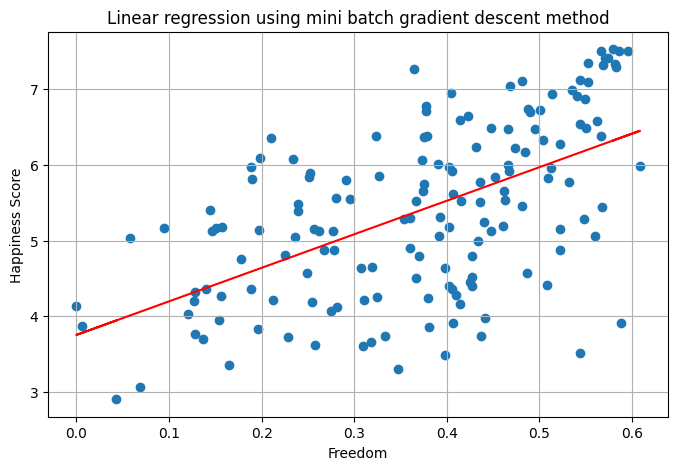

In [12]:
from mini_batch_gd import Linear_Regression_Mini_Batch

X = df['Freedom'].to_numpy()
y = df['Happiness Score'].to_numpy()

mini_batch = Linear_Regression_Mini_Batch()
mini_batch.fit(X, y, max_iters=100, lr=0.3, stats=True)

y_pred = mini_batch.predict(X)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, label='Data')
plt.plot(X, y_pred, color='red', label='Mini batch gradient descent')
plt.grid()
plt.xlabel('Freedom')
plt.ylabel('Happiness Score')
plt.title('Linear regression using mini batch gradient descent method')

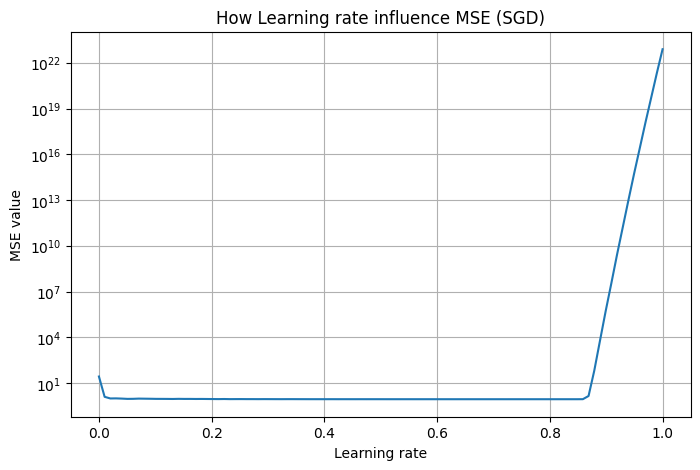

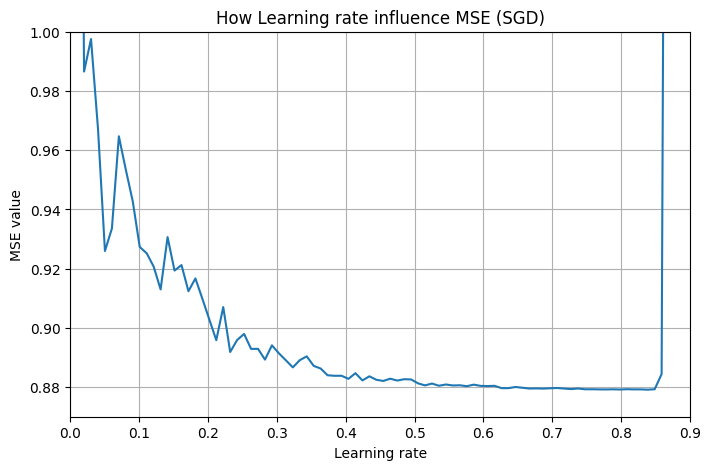

In [13]:
# === Learning rate test ===
learning_rate = np.linspace(0, 1, 100)
errors = []

for alpha in learning_rate:
    lr_test = Linear_Regression_Mini_Batch()
    gradient_descent.fit(X, y, max_iters=100, lr=alpha, stats=False)
    y_pred = gradient_descent.predict(X)

    errors.append(MSE(y, y_pred))

plt.figure(figsize=(8, 5))
plt.plot(learning_rate, errors)
plt.yscale('log')
plt.xlabel('Learning rate')
plt.ylabel('MSE value')
plt.title('How Learning rate influence MSE (SGD)')
plt.grid()

plt.figure(figsize=(8, 5))
plt.plot(learning_rate, errors)
plt.xlim(0, 0.9)
plt.ylim(0.87, 1)
plt.xlabel('Learning rate')
plt.ylabel('MSE value')
plt.title('How Learning rate influence MSE (SGD)')
plt.grid()

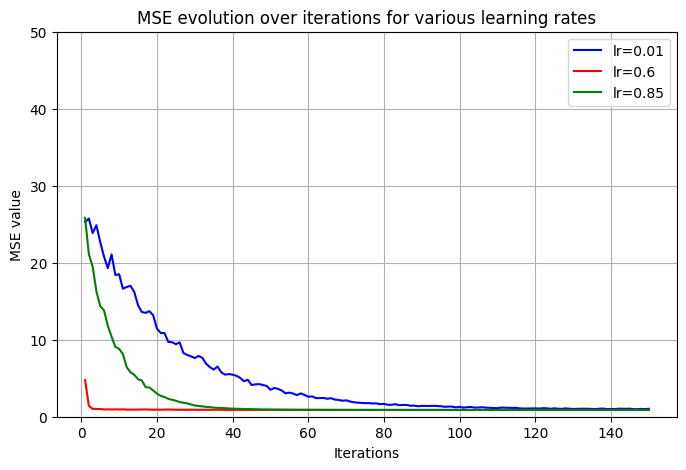

In [14]:
# === Iteration test ===
iterations = np.linspace(1, 150, 150, dtype=int)
learning_rate = [0.01, 0.6, 0.85]

errors = []
for alpha in learning_rate:
    error = []
    for iter in iterations:
        iter_test = Linear_Regression_Mini_Batch()
        gradient_descent.fit(X, y, max_iters=iter, lr=alpha, stats=False)
        y_pred = gradient_descent.predict(X)

        error.append(MSE(y, y_pred))
    errors.append(error)


plt.figure(figsize=(8, 5))
plt.plot(iterations, errors[0], color='blue', label=f'lr={learning_rate[0]}')
plt.plot(iterations, errors[1], color='red', label=f'lr={learning_rate[1]}')
plt.plot(iterations, errors[2], color ='green', label=f'lr={learning_rate[2]}')
plt.ylim(0, 50)
plt.xlabel('Iterations')
plt.ylabel('MSE value')
plt.title('MSE evolution over iterations for various learning rates')
plt.legend()
plt.grid()

---

### **Singular Value Decomposition (SVD)**

Final RMSE: [1.04201095]
Final Function: y = [[4.13362939]]x + [4.8132991]


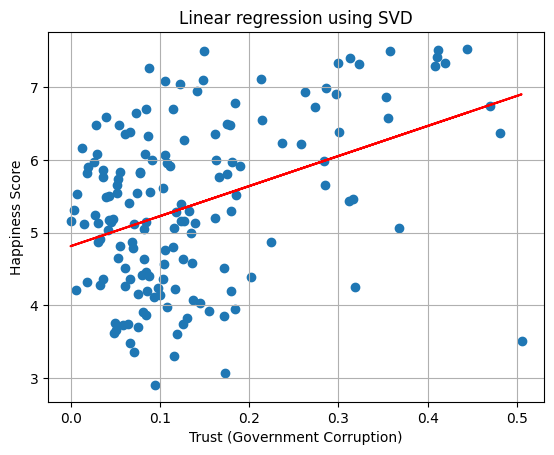

In [15]:
from svd import Linear_Regression_SVD

X = df['Trust (Government Corruption)'].to_numpy()
y = df['Happiness Score'].to_numpy()

svd = Linear_Regression_SVD()
svd.fit(X, y)

y_pred = svd.predict(X)

print(f'Final RMSE: {RMSE(y, y_pred)}')
print(f'Final Function: y = {svd.weights}x + {svd.bias}')
plt.scatter(X, y, label='Data')
plt.plot(X, y_pred, color='red', label='SVD')
plt.xlabel('Trust (Government Corruption)')
plt.ylabel('Happiness Score')
plt.title('Linear regression using SVD')
plt.grid()

Closed Form
Final RMSE:
0.6972626334828966
Final function:
y = [2.18686322]X + 3.296180041308007
SVD
Final RMSE:
[0.69726263]
Final function:
y = [[2.18686322]]X + [3.29618004]


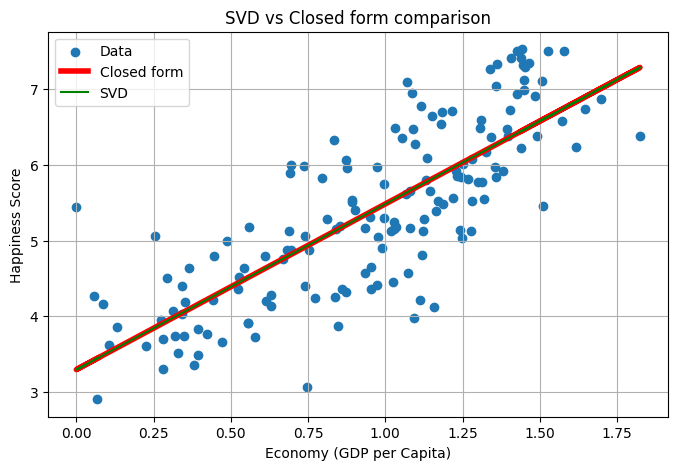

In [16]:
# SVD vs Closed form comparison

X = df['Economy (GDP per Capita)'].to_numpy()
y = df['Happiness Score'].to_numpy()

closed_form = Linear_Regression_Closed_Form()
closed_form.fit(X, y)

svd = Linear_Regression_SVD()
svd.fit(X, y)

y_cf = closed_form.predict(X)
y_svd = svd.predict(X)

print('Closed Form')
print(f'Final RMSE:\n{RMSE(y, y_cf)}')
print(f'Final function:\ny = {closed_form.weights}X + {closed_form.bias}')


print('SVD')
print(f'Final RMSE:\n{RMSE(y, y_svd)}')
print(f'Final function:\ny = {svd.weights}X + {svd.bias}')

plt.figure(figsize=(8, 5))
plt.scatter(X, y, label='Data')
plt.plot(X, y_cf, color='red', linewidth=4, label='Closed form')
plt.plot(X, y_svd, color='green', label='SVD')
plt.grid(True)
plt.title('SVD vs Closed form comparison')
plt.xlabel('Economy (GDP per Capita)')
plt.ylabel('Happiness Score')
plt.legend()


---

### **Ridge**

Final RMSE:
[0.6974607]
Final function:
y = [[2.14645055]]X + [3.33472887]


Text(0, 0.5, 'Happiness Score')

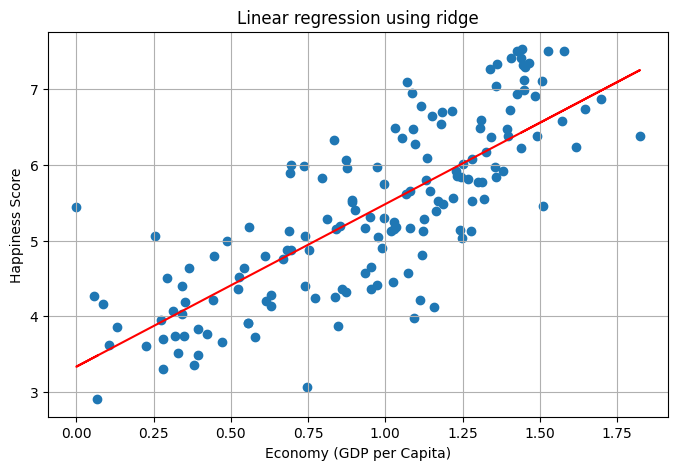

In [17]:
from ridge import Linear_Regression_Ridge

X = df['Economy (GDP per Capita)'].to_numpy()
y = df['Happiness Score'].to_numpy()

ridge = Linear_Regression_Ridge()
ridge.fit(X, y, alpha=0.5)

y_pred = ridge.predict(X)

print(f'Final RMSE:\n{RMSE(y, y_pred)}')
print(f'Final function:\ny = {ridge.weights}X + {ridge.bias}')

plt.figure(figsize=(8, 5))
plt.scatter(X, y, label='Data')
plt.plot(X, y_pred, color='red', label='Closed form')
plt.grid(True)
plt.title('Linear regression using ridge')
plt.xlabel('Economy (GDP per Capita)')
plt.ylabel('Happiness Score')

RMSE for alpha=0: [0.69726263]
RMSE for alpha=0.1: [0.6972708]
RMSE for alpha=1: [0.69802612]
RMSE for alpha=5: [0.71167658]
RMSE for alpha=10: [0.73939641]
RMSE for alpha=50: [0.91171945]
RMSE for alpha=100: [0.99561029]


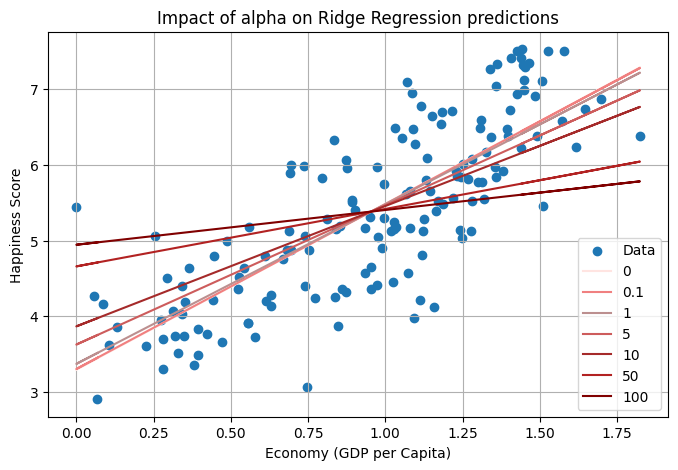

In [18]:
# === Alpha test ===
X = df['Economy (GDP per Capita)'].to_numpy()
y = df['Happiness Score'].to_numpy()

alphas = [0, 0.1, 1, 5, 10, 50, 100]
colors = [
    'mistyrose',
    'lightcoral',
    'rosybrown',
    'indianred',
    'brown',
    'firebrick',
    'maroon'
]

plt.figure(figsize=(8, 5))
plt.scatter(X, y, label='Data')

for alpha, color in zip(alphas, colors):
    ridge = Linear_Regression_Ridge()
    ridge.fit(X, y, alpha=alpha)

    y_pred = ridge.predict(X)

    print(f'RMSE for alpha={alpha}: {RMSE(y, y_pred)}')

    plt.plot(X, y_pred, color=color, label=alpha)

plt.grid()
plt.xlabel('Economy (GDP per Capita)')
plt.ylabel('Happiness Score')
plt.title("Impact of alpha on Ridge Regression predictions")
plt.legend()

---

### **~~Lasso~~** work in progress

In [19]:
# from lasso import Linear_Regression_Lasso

# X = df['Economy (GDP per Capita)'].to_numpy()
# y = df['Happiness Score'].to_numpy()

# ridge = Linear_Regression_Lasso()
# ridge.fit(X, y, alpha=0.5, max_iters=10, lr=0.1, stats=False)

# y_pred = ridge.predict(X)

# print(f'Final RMSE:\n{RMSE(y, y_pred)}')
# print(f'Final function:\ny = {ridge.weights}X + {ridge.bias}')

# plt.figure(figsize=(8, 5))
# plt.scatter(X, y, label='Data')
# plt.plot(X, y_pred, color='red', label='Closed form')
# plt.grid(True)
# plt.title('Linear regression using ridge')
# plt.xlabel('Economy (GDP per Capita)')
# plt.ylabel('Happiness Score')

---

### **Polynomial regression**

Text(0.5, 1.0, 'Polynomial regression using mini-batch method')

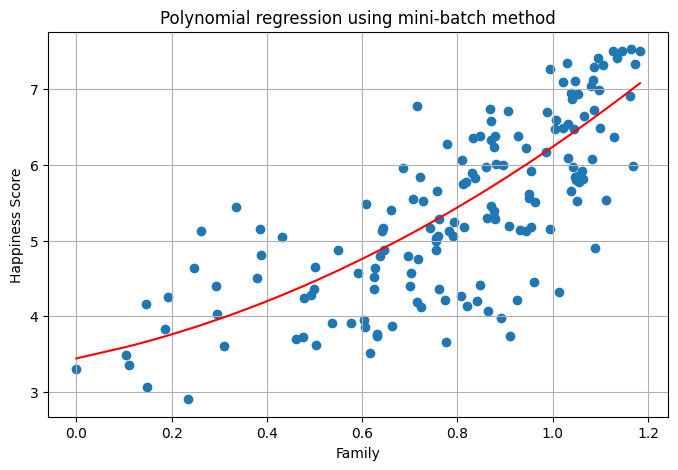

In [20]:
from polynomial_regression import Linear_Regression_Polynomial

X = df['Family'].to_numpy()
y = df['Happiness Score'].to_numpy()

polynomial = Linear_Regression_Polynomial()

X_poly = polynomial.transform(X, power=2)

mini_batch = Linear_Regression_Mini_Batch()

mini_batch.fit(X_poly, y, max_iters=100, lr=0.2, stats=False)
y_pred = mini_batch.predict(X_poly)


plt.figure(figsize=(8, 5))
plt.scatter(X, y)
sort_idx = np.argsort(X)
plt.plot(X[sort_idx], y_pred[sort_idx], color='red')
plt.grid()
plt.xlabel('Family')
plt.ylabel('Happiness Score')
plt.title('Polynomial regression using mini-batch method')

---

### **Time comparison**

In [30]:
import time
features = [
    'Economy (GDP per Capita)',
    'Family', 
    'Health (Life Expectancy)', 
    'Freedom',
    'Trust (Government Corruption)', 
    'Generosity',
    'Dystopia Residual'
]
algorithm = [
    'Closed form',
    'Gradient descent',
    'Stochastic gradient descent',
    'Mini-batch gradient descent',
    'Singular value decomposiotion',
    'Ridge'
]
X = df[features].to_numpy()
y = df['Happiness Score'].to_numpy()

cf = []
gd = []
sgd = []
batch = []
svd = []
ridge = []

for _ in range (10):
    start = time.time()
    regression = Linear_Regression_Closed_Form()
    regression.fit(X, y)
    end = time.time()
    cf.append(end - start)

    start = time.time()
    regression = Linear_Regression_Gradient()
    regression.fit(X, y, max_iters=10, lr=0.4)
    end = time.time()
    gd.append(end - start)

    start = time.time()
    regression = Linear_Regression_Stochastic_GD()
    regression.fit(X, y, max_iters=10, lr=0.4)
    end = time.time()
    sgd.append(end - start)

    start = time.time()
    regression = Linear_Regression_Mini_Batch()
    regression.fit(X, y, max_iters=10, lr=0.4)
    end = time.time()
    batch.append(end - start)

    start = time.time()
    regression = Linear_Regression_SVD()
    regression.fit(X, y)
    end = time.time()
    svd.append(end - start)

    start = time.time()
    regression = Linear_Regression_Ridge()
    regression.fit(X, y, alpha=0.2)
    end = time.time()
    ridge.append(end - start)

df_times = pd.DataFrame({
    'Algorithm' : algorithm,
    'Mean Time (s)': [
        np.mean(cf),
        np.mean(gd),
        np.mean(sgd),
        np.mean(batch),
        np.mean(svd),
        np.mean(ridge)
    ]
})

df_times

c:\Users\pando\Desktop\ML_AI\machine_learning_from_scratch\01_linear_regression\stochastic_gd.py:53: RuntimeWarning: overflow encountered in matmul
  dw = 2 * Xi.T @ error
c:\Users\pando\Desktop\ML_AI\machine_learning_from_scratch\01_linear_regression\stochastic_gd.py:56: RuntimeWarning: invalid value encountered in subtract
  self.weights = self.weights - (lr * dw)
c:\Users\pando\Desktop\ML_AI\machine_learning_from_scratch\01_linear_regression\stochastic_gd.py:54: RuntimeWarning: overflow encountered in scalar multiply
  db = 2 * np.sum(error)
c:\Users\pando\Desktop\ML_AI\machine_learning_from_scratch\01_linear_regression\stochastic_gd.py:57: RuntimeWarning: invalid value encountered in scalar subtract
  self.bias = self.bias - (lr * db)
c:\Users\pando\Desktop\ML_AI\machine_learning_from_scratch\01_linear_regression\stochastic_gd.py:49: RuntimeWarning: invalid value encountered in matmul
  yi_pred = Xi @ self.weights + self.bias


,Algorithm,Mean Time (s)
0,Closed form,0.000030
1,Gradient descent,0.000097
2,Stochastic gradient descent,0.011223
3,Mini-batch gradient descent,0.000532
4,Singular value decomposiotion,0.000118
5,Ridge,0.000037
